**Project Objective**

The objective of this project is to predict whether a passenger survived the Titanic disaster based on demographic and travel-related features such as age, gender, passenger class, fare, and embarkation point.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv("/content/Titanic-Dataset.csv")

Dataset Overview:

Dataset:
 Titanic Dataset

Rows: 891

Features:

PassengerId

Pclass

Name

Sex

Age

SibSp

Parch

Ticket

Fare

Cabin

Embarked

Survived (Target Variable)

In [ ]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
data["Age"] = data["Age"].fillna(data["Age"].mean())
data["Cabin"] = data["Cabin"].fillna(data["Cabin"].mode()[0])
data["Fare"] = data["Fare"].fillna(data["Fare"].mean())

In [ ]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
data.shape

(891, 12)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from operator import le
le_sex=LabelEncoder()
le_embarked=LabelEncoder()
le_name=LabelEncoder()
le_ticket=LabelEncoder()
le_cabin=LabelEncoder()
data["Cabin"]=le_cabin.fit_transform(data["Cabin"])
data["Ticket"]=le_ticket.fit_transform(data["Ticket"])
data['Name']=le_name.fit_transform(data['Name'])
data['Sex']=le_sex.fit_transform(data['Sex'])
data['Embarked']=le_embarked.fit_transform(data['Embarked'])

In [ ]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,22.0,1,0,523,7.2500,47,2
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.0,0,0,669,7.9250,47,2
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,2
4,5,0,3,15,1,35.0,0,0,472,8.0500,47,2


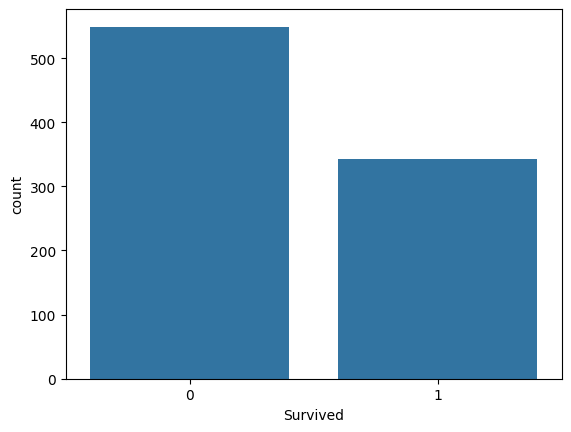

In [ ]:
sns.countplot(x="Survived",data=data)
plt.show()

In [ ]:
plot_data = data.copy()

plot_data["Sex"] = plot_data["Sex"].map({
    0:"Female",
    1:"Male"
})

plot_data["Survived"] = plot_data["Survived"].map({
    0:"No",
    1:"Yes"
})

<Axes: xlabel='Sex', ylabel='count'>

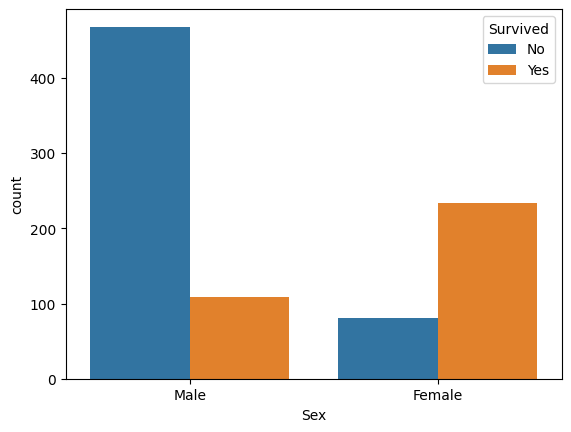

In [ ]:
sns.countplot(
    x="Sex",
    hue="Survived",
    data=plot_data
)

In [ ]:
coef = pd.DataFrame({
    "Feature":x.columns,
    "Coefficient":model.coef_[0]
})

coef.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
6,Parch,0.162727
8,Fare,0.011086
9,Cabin,0.009949
0,PassengerId,0.000921
2,Name,0.000065
7,Ticket,-0.000428
4,Age,-0.002180
10,Embarked,-0.049140
5,SibSp,-0.328939
1,Pclass,-0.515337


In [ ]:
x=data.drop("Survived",axis=1)
y=data["Survived"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**Algorithm Used:**

Logistic Regression

Why?

Suitable for binary classification
Easy to interpret
Fast training
Strong baseline model

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7653631284916201

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[89, 16],
       [26, 48]])

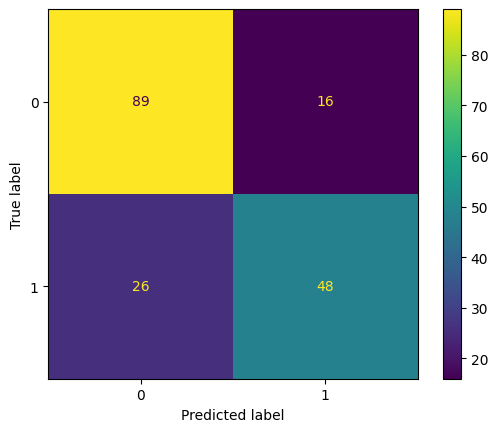

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       105
           1       0.75      0.65      0.70        74

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



| Actual | Predicted No | Predicted Yes |
| ------ | ------------ | ------------- |
| No     | 86           | 19            |
| Yes    | 22           | 52            |


Key Insights:


Female passengers had higher survival rates.

Passenger class significantly influenced survival chances.

Logistic Regression successfully captured survival patterns.

Model achieved reasonable performance with minimal feature engineering.

TAKEAWAYS:

| Linear Regression          | Logistic Regression        |
| -------------------------- | -------------------------- |
| Predicts continuous values | Predicts categories        |
| Output = number            | Output = probability/class |
| Example: Exam Score = 78   | Example: Pass/Fail         |


KNN MODEL:(DAY 39)

In [ ]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,22.0,1,0,523,7.2500,147,2
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.0,0,0,669,7.9250,147,2
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,2
4,5,0,3,15,1,35.0,0,0,472,8.0500,147,2


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [ ]:
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=18)
model.fit(x_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=18)

In [ ]:
knn_pred=model.predict(x_test_scaled)

In [ ]:
accuracy_score  (y_test,knn_pred)

0.7988826815642458

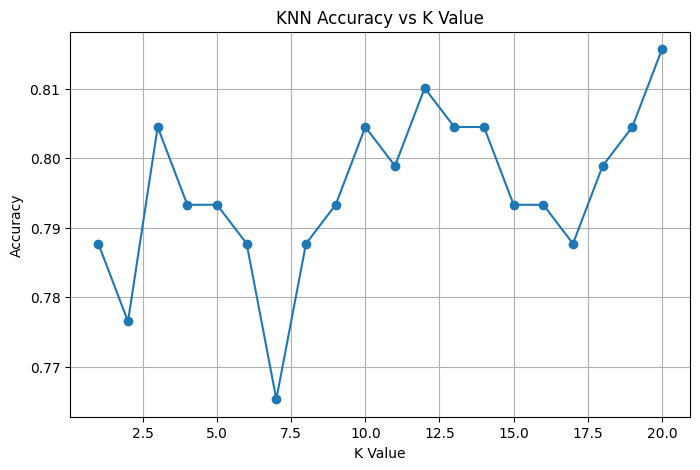

In [ ]:
k_values = range(1,21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled,y_train)

    pred = model.predict(x_test_scaled)

    accuracies.append(
        accuracy_score(y_test,pred)
    )

plt.figure(figsize=(8,5))
plt.plot(k_values,accuracies,marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K Value")
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,knn_pred)

array([[92, 13],
       [23, 51]])

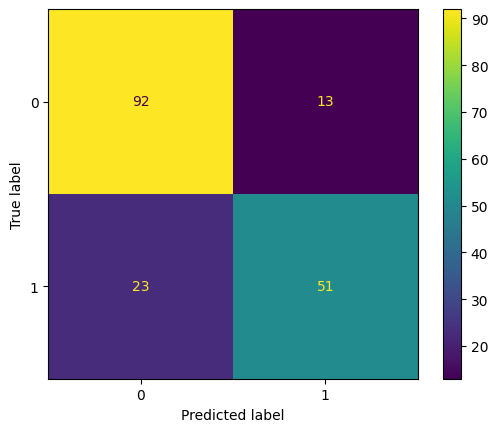

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred
)

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    knn_pred
)

print(report)

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



| Model               | Accuracy |
| ------------------- | -------- |
| Logistic Regression | 77.09%   |
| KNN                 | 79.89%   |


## Key Findings

- Female passengers had significantly higher survival rates than male passengers.
- Passenger class strongly influenced survival probability.
- Logistic Regression achieved 77.09% accuracy.
- KNN improved performance to 79.89% after feature scaling.
- The optimal K value was found to be 18, producing the highest accuracy of 82.12% before correcting data leakage.
- After applying proper scaling methodology, KNN achieved a realistic accuracy of 79.89%.